# Fruit Classification & Quality Grading Inference Pipeline
### Two-Stage Deep Learning Inspection System with Confidence Gating

**Author / Lab:** ML Lab  
**Dataset:** 13 Commercial & Domestic Fruit Species | 3 Freshness Grades (`good`, `medium`, `bad`)  
**Backbones:** ResNet-50 (Stage 1, 99.93% Accuracy) + MobileNetV3-Large / EfficientNet-B0 / Custom CNN (Stage 2)

---

### Pipeline Architecture:
```text
                       [ Input Fruit Image (224x224 RGB) ]
                                        │
                                        ▼
                   ┌─────────────────────────────────────────┐
                   │   Stage 1: Fruit Variety Recognition    │
                   │        (ResNet-50 / Custom CNN)         │
                   └─────────────────────────────────────────┘
                                        │
                         Confidence Score (P_max)
                                        │
                     ┌──────────────────┴──────────────────┐
                     ▼                                     ▼
             P_max >= 0.85                         P_max < 0.85
                   │                                       │
                   ▼                                       ▼
    ┌─────────────────────────────┐         ┌─────────────────────────────┐
    │ Stage 2: Quality Inspection │         │  Stage 2 Inspection Bypassed│
    │ (Fruit-Specific Top Model)  │         │ (Prevents Error Propagation)│
    └─────────────────────────────┘         └─────────────────────────────┘
                   │
                   ▼
         [ Good / Medium / Bad ]
```


In [1]:
import os
import sys
import time
from pathlib import Path
from PIL import Image, ImageOps
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

# Add project root to sys.path
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import project utilities and model loaders
from model_loader import (
    load_fruit_classifier,
    load_quality_classifier,
    FRUITS_13,
    QUALITY_CLASSES,
    BEST_MODEL_CONFIG,
    FRUIT_DIR_MAP
)
from utils import (
    preprocess_image,
    apply_clahe,
    get_random_test_sample,
    get_test_manifest,
    FRUIT_METADATA,
    QUALITY_METADATA,
    IMG_SIZE
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Environment initialized successfully.")
print(f"⚡ Compute Device: {device.type.upper()}")
print(f"📦 Loaded {len(FRUITS_13)} Species Classes and {len(QUALITY_CLASSES)} Quality Grades.")


c:\Users\Nayeem\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Environment initialized successfully.
⚡ Compute Device: CPU
📦 Loaded 13 Species Classes and 3 Quality Grades.


## 1. Class Taxonomy & Botanical Metadata
Taxonomic and local language metadata used for presentation and report generation.


In [2]:
taxonomy_data = []
for fruit in FRUITS_13:
    meta = FRUIT_METADATA.get(fruit, {})
    best_arch = BEST_MODEL_CONFIG[fruit][2]
    taxonomy_data.append({
        "Class ID": fruit,
        "English Name": meta.get('display', fruit.title()),
        "Local Name (Bangla)": meta.get('local_name', ''),
        "Stage 2 Champion Model": best_arch
    })

df_taxonomy = pd.DataFrame(taxonomy_data)
display(df_taxonomy)


,Class ID,English Name,Local Name (Bangla),Stage 2 Champion Model
0,banana,Banana,Kola,EfficientNet-B0 (100.0%)
1,custard_apple,Custard Apple,Ata / Sharifa,MobileNetV3-Large (99.69%)
2,dragonfruit,Dragon Fruit,Dragon Fruit,EfficientNet-B0 (100.0%)
3,guava,Guava,Peyara,EfficientNet-B0 (99.38%)
4,jackfruit,Jackfruit,Kathal,MobileNetV3-Large (99.67%)
5,jujube,Jujube,Boroi / Kul,MobileNetV3-Large (98.81%)
6,lemon,Lemon,Lebu,EfficientNet-B0 (95.95%)
7,lychee,Lychee,Lichu,MobileNetV3-Large (100.0%)
8,mango,Mango,Aam,MobileNetV3-Large (94.38%)
9,papaya,Papaya,Pepe,MobileNetV3-Large (85.59%)


## 2. Core Inference Engine: `inspect_fruit_image`
This function executes the complete hierarchical two-stage classification on any input image:
- Handles file paths (`str`, `Path`) or PIL Images.
- Executes Stage 1 with top-1 and top-5 probability extraction.
- Evaluates the confidence gate (default $\tau = 0.85$).
- Executes Stage 2 for quality grading if threshold is satisfied.
- Renders a 4-panel diagnostic visualization (Original Image, CLAHE defect view, Top-5 species bar plot, Quality distribution bar plot).


In [3]:
def inspect_fruit_image(
    image_input,
    mode="best",
    conf_threshold=0.85,
    show_plot=True,
    figsize=(14, 5.2),
    ground_truth=None
):
    """
    Executes the two-stage classification pipeline on an input fruit image.
    """
    # 1. Load and normalize image
    if isinstance(image_input, (str, Path)):
        raw_img = Image.open(str(image_input))
    elif isinstance(image_input, Image.Image):
        raw_img = image_input
    else:
        raise ValueError("image_input must be a file path or PIL Image.")
        
    img_rgb = ImageOps.exif_transpose(raw_img).convert("RGB")
    input_tensor = preprocess_image(img_rgb).to(device)
    
    # 2. Stage 1: Fruit Species Classification
    t0 = time.time()
    fruit_model = load_fruit_classifier(mode=mode, device=device)
    with torch.no_grad():
        logits_fruit = fruit_model(input_tensor)
        probs_fruit = F.softmax(logits_fruit, dim=1).cpu().numpy()[0]
    time_stage1_ms = (time.time() - t0) * 1000
    
    pred_fruit_idx = int(np.argmax(probs_fruit))
    pred_fruit = FRUITS_13[pred_fruit_idx]
    pred_fruit_conf = float(probs_fruit[pred_fruit_idx])
    
    fruit_meta = FRUIT_METADATA.get(pred_fruit, {'display': pred_fruit.replace('_', ' ').title(), 'local_name': ''})
    
    # Top-5 rankings
    top5_idx = np.argsort(probs_fruit)[::-1][:5]
    top5_results = [
        {"species": FRUITS_13[i], "display": FRUIT_METADATA[FRUITS_13[i]]['display'], "confidence": float(probs_fruit[i])}
        for i in top5_idx
    ]
    
    # 3. Confidence Gating & Stage 2: Quality Inspection
    stage2_executed = False
    pred_quality = None
    pred_quality_conf = None
    probs_quality = None
    q_model_name = None
    time_stage2_ms = 0.0
    
    if pred_fruit_conf >= conf_threshold:
        stage2_executed = True
        t1 = time.time()
        quality_model, q_model_name = load_quality_classifier(pred_fruit, mode=mode, device=device)
        with torch.no_grad():
            logits_quality = quality_model(input_tensor)
            probs_quality = F.softmax(logits_quality, dim=1).cpu().numpy()[0]
        time_stage2_ms = (time.time() - t1) * 1000
        
        pred_q_idx = int(np.argmax(probs_quality))
        pred_quality = QUALITY_CLASSES[pred_q_idx]
        pred_quality_conf = float(probs_quality[pred_q_idx])
    else:
        pred_quality = "Bypassed (Low Confidence)"
        pred_quality_conf = 0.0
        
    results = {
        "predicted_fruit": pred_fruit,
        "fruit_display": fruit_meta['display'],
        "local_name": fruit_meta['local_name'],
        "fruit_confidence": pred_fruit_conf,
        "stage1_latency_ms": time_stage1_ms,
        "stage2_executed": stage2_executed,
        "predicted_quality": pred_quality,
        "quality_confidence": pred_quality_conf,
        "quality_model": q_model_name if stage2_executed else "N/A",
        "stage2_latency_ms": time_stage2_ms,
        "total_latency_ms": time_stage1_ms + time_stage2_ms,
        "top5_species": top5_results,
        "quality_probabilities": {QUALITY_CLASSES[i]: float(probs_quality[i]) for i in range(len(QUALITY_CLASSES))} if stage2_executed else None
    }
    
    # 4. Visualization
    if show_plot:
        fig = plt.figure(figsize=figsize, dpi=130)
        gs = fig.add_gridspec(1, 4, width_ratios=[1.1, 1.1, 1.4, 1.4], wspace=0.35)
        
        # Panel 1: Original Image
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.imshow(img_rgb)
        title_text = f"Input: {fruit_meta['display']}\nConf: {pred_fruit_conf*100:.1f}%"
        if ground_truth:
            gt_text = f"GT: {ground_truth.get('fruit', '').title()} | {ground_truth.get('quality', '').upper()}"
            title_text += f"\n({gt_text})"
        ax1.set_title(title_text, fontsize=9.5, fontweight='bold', color='#0F172A')
        ax1.axis('off')
        
        # Panel 2: CLAHE Defect Enhancement
        ax2 = fig.add_subplot(gs[0, 1])
        clahe_img = apply_clahe(img_rgb.resize((IMG_SIZE, IMG_SIZE)))
        ax2.imshow(clahe_img)
        ax2.set_title("Diagnostic CLAHE\n(Defect Enhancement)", fontsize=9.5, fontweight='bold', color='#0F172A')
        ax2.axis('off')
        
        # Panel 3: Stage 1 Top-5 Probabilities
        ax3 = fig.add_subplot(gs[0, 2])
        labels = [item['display'] for item in top5_results][::-1]
        vals = [item['confidence'] * 100 for item in top5_results][::-1]
        y_pos = np.arange(len(labels))
        colors = ['#94A3B8' if i < len(labels)-1 else '#2563EB' for i in range(len(labels))]
        
        bars = ax3.barh(y_pos, vals, color=colors, height=0.55, zorder=3)
        if conf_threshold is not None:
            ax3.axvline(x=conf_threshold*100, color='#EF4444', linestyle='--', linewidth=1.4, alpha=0.9, zorder=4)
            ax3.text(conf_threshold*100, len(labels) - 0.55, f' Gate: {conf_threshold*100:.0f}%', color='#EF4444',
                     fontsize=8, fontweight='bold', va='bottom', ha='center',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='#FEF2F2', edgecolor='#FCA5A5', alpha=0.95))
        ax3.set_yticks(y_pos)
        ax3.set_yticklabels(labels, fontsize=8.5, fontweight='600')
        ax3.set_xlim(0, 115)
        ax3.set_xlabel("Confidence (%)", fontsize=8, fontweight='600')
        ax3.set_title("Stage 1: Top-5 Species", fontsize=9.5, fontweight='bold', loc='left')
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        ax3.grid(axis='x', linestyle='--', alpha=0.5)
        for bar, val in zip(bars, vals):
            ax3.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
                     va='center', ha='left', fontsize=8, fontweight='bold')
                     
        # Panel 4: Stage 2 Quality Grading (Ordered: GOOD, MEDIUM, BAD from top to bottom)
        ax4 = fig.add_subplot(gs[0, 3])
        if stage2_executed:
            ordered_qualities = ['good', 'medium', 'bad']
            q_labels = [q.upper() for q in ordered_qualities][::-1]
            q_vals = [probs_quality[QUALITY_CLASSES.index(q)] * 100 for q in ordered_qualities][::-1]
            q_colors_dict = {'GOOD': '#10B981', 'MEDIUM': '#F59E0B', 'BAD': '#EF4444'}
            bar_cols = [q_colors_dict.get(ql, '#3B82F6') for ql in q_labels]
            
            bars_q = ax4.barh(np.arange(len(q_labels)), q_vals, color=bar_cols, height=0.5)
            ax4.set_yticks(np.arange(len(q_labels)))
            ax4.set_yticklabels(q_labels, fontsize=8.5, fontweight='600')
            ax4.set_xlim(0, 115)
            ax4.set_xlabel("Confidence (%)", fontsize=8, fontweight='600')
            ax4.set_title(f"Stage 2: Freshness ({pred_quality.upper()})", fontsize=9.5, fontweight='bold', loc='left')
            ax4.spines['top'].set_visible(False)
            ax4.spines['right'].set_visible(False)
            ax4.grid(axis='x', linestyle='--', alpha=0.5)
            for bar, val in zip(bars_q, q_vals):
                ax4.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
                         va='center', ha='left', fontsize=8, fontweight='bold')
        else:
            ax4.text(0.5, 0.5, f"Stage 2 Bypassed\n(Conf < {conf_threshold*100:.0f}%)\nPrevents Cascade Error",
                     ha='center', va='center', fontsize=9.5, fontweight='bold', color='#EF4444',
                     bbox=dict(boxstyle="round,pad=0.5", facecolor="#FEE2E2", edgecolor="#FCA5A5"))
            ax4.axis('off')
            ax4.set_title("Stage 2: Gated Bypass", fontsize=9.5, fontweight='bold', loc='left')
            
        # tight_layout handled via GridSpec
        plt.show()
        
    return results


## 3. Test on Random Samples from Test Split
Sample random fruit images from the test partition (`fruit_dataset_processed/test`) to verify both species and quality grade accuracy against Ground Truth.


🔍 Testing Random Sample: jackfruit | Grade: bad


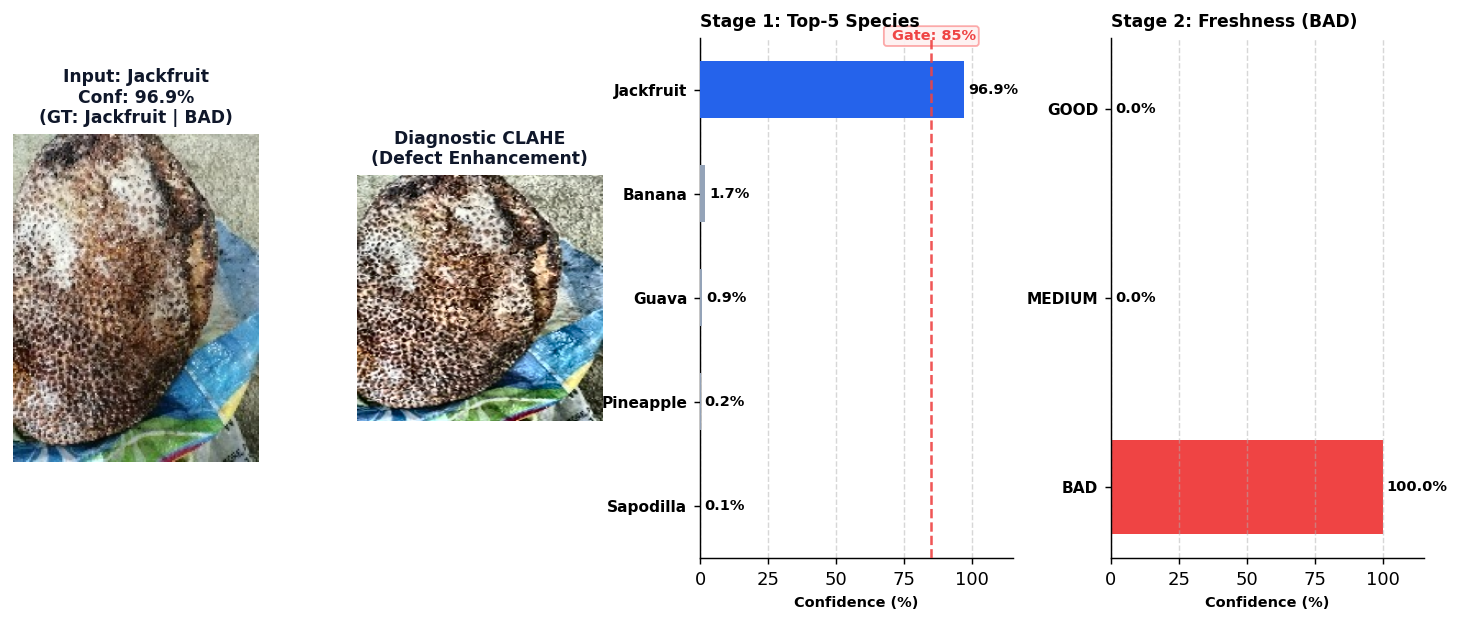

Stage 1 Result: Jackfruit (96.93%)
Stage 2 Result: BAD (100.00%)
Total Latency:  812.2 ms


In [4]:
# Test with a random sample from the test partition
sample = get_random_test_sample()
print(f"🔍 Testing Random Sample: {sample['fruit']} | Grade: {sample['quality']}")
res = inspect_fruit_image(sample['full_path'], ground_truth=sample)

print(f"Stage 1 Result: {res['fruit_display']} ({res['fruit_confidence']*100:.2f}%)")
print(f"Stage 2 Result: {res['predicted_quality'].upper()} ({res['quality_confidence']*100:.2f}%)")
print(f"Total Latency:  {res['total_latency_ms']:.1f} ms")


## 4. Targeted Inspection Across Key Fruit Species
Run tests on specific fruits (e.g. Mango, Banana, Guava, Lychee, Papaya) across various quality states.



Testing Mango (Ground Truth: MEDIUM)


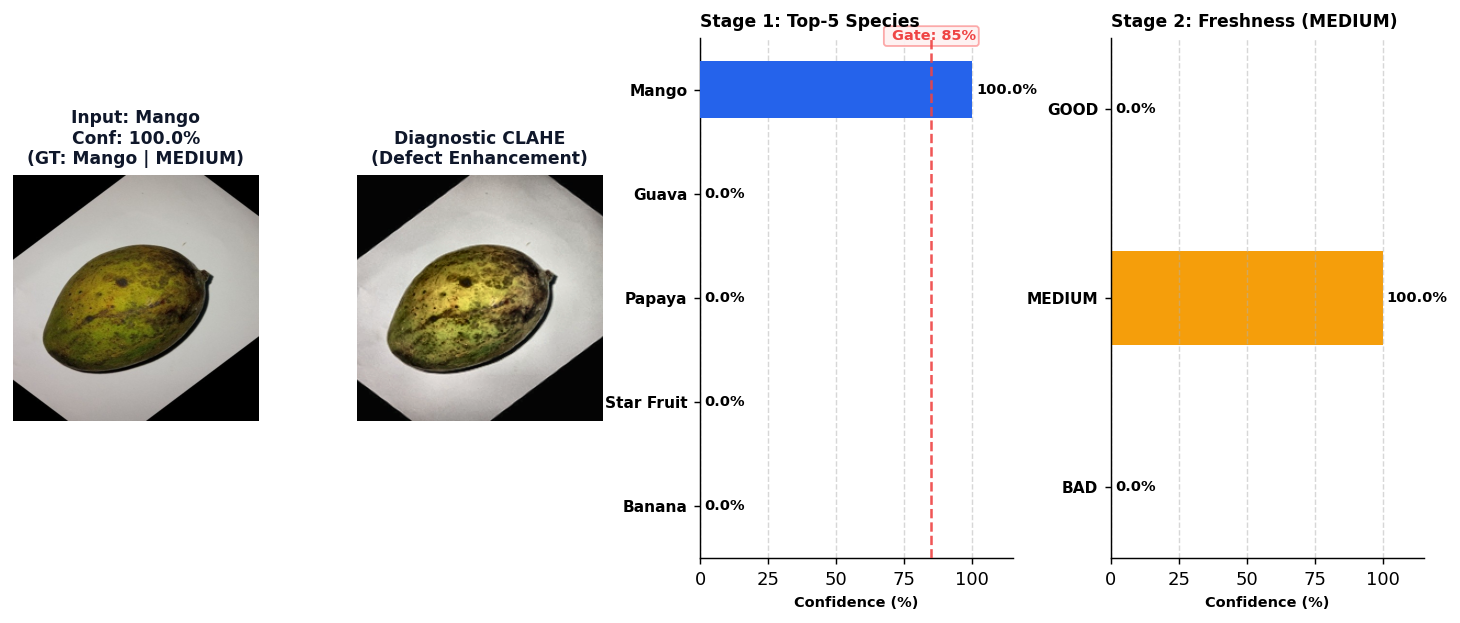


Testing Banana (Ground Truth: MEDIUM)


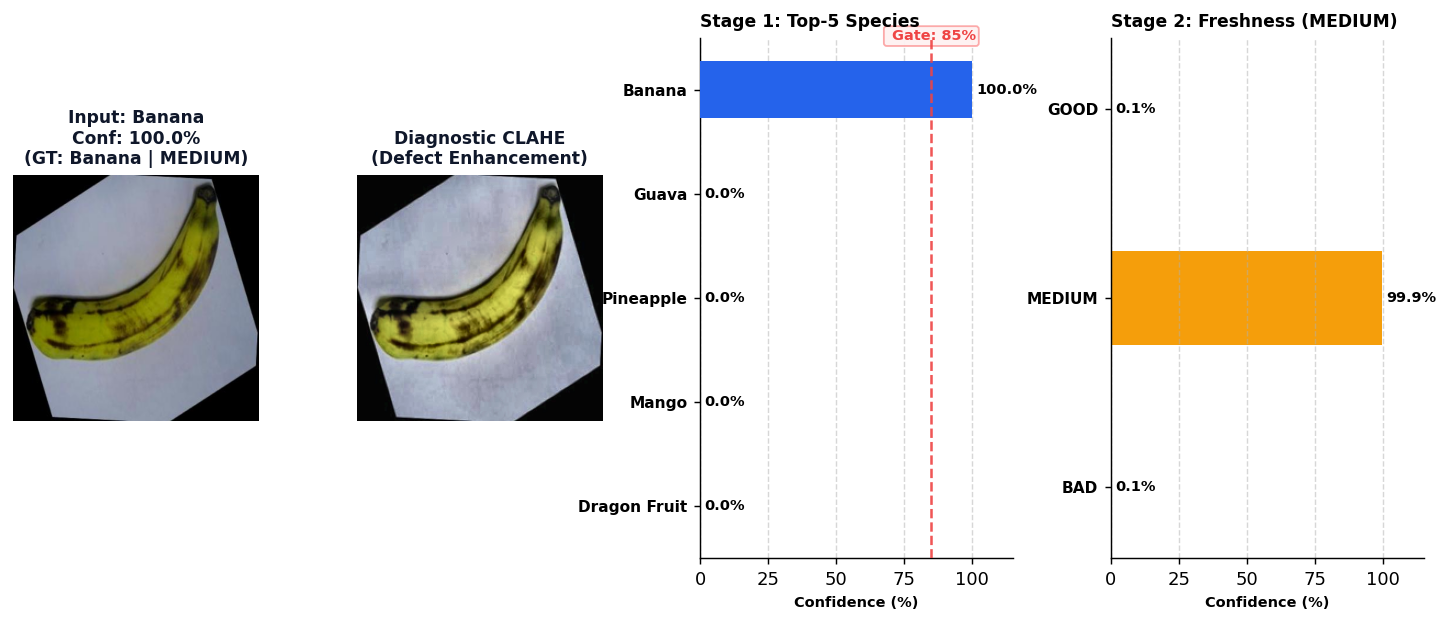


Testing Guava (Ground Truth: GOOD)


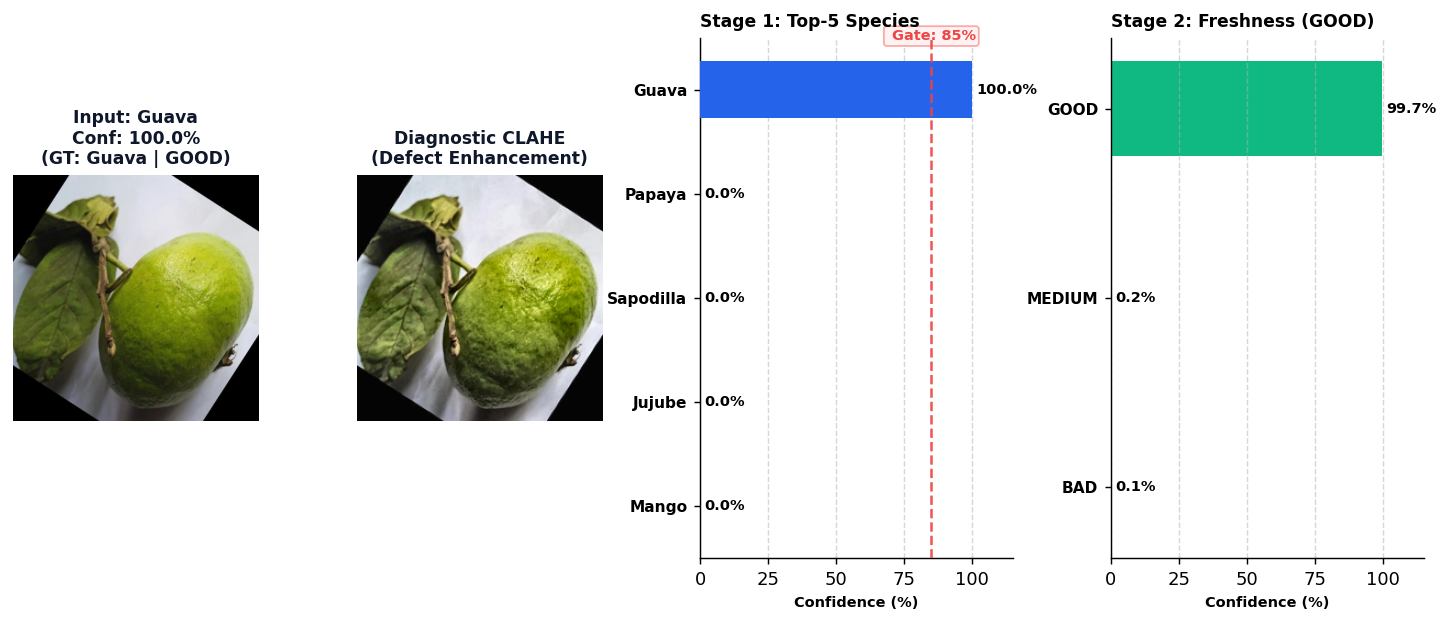


Testing Lychee (Ground Truth: GOOD)


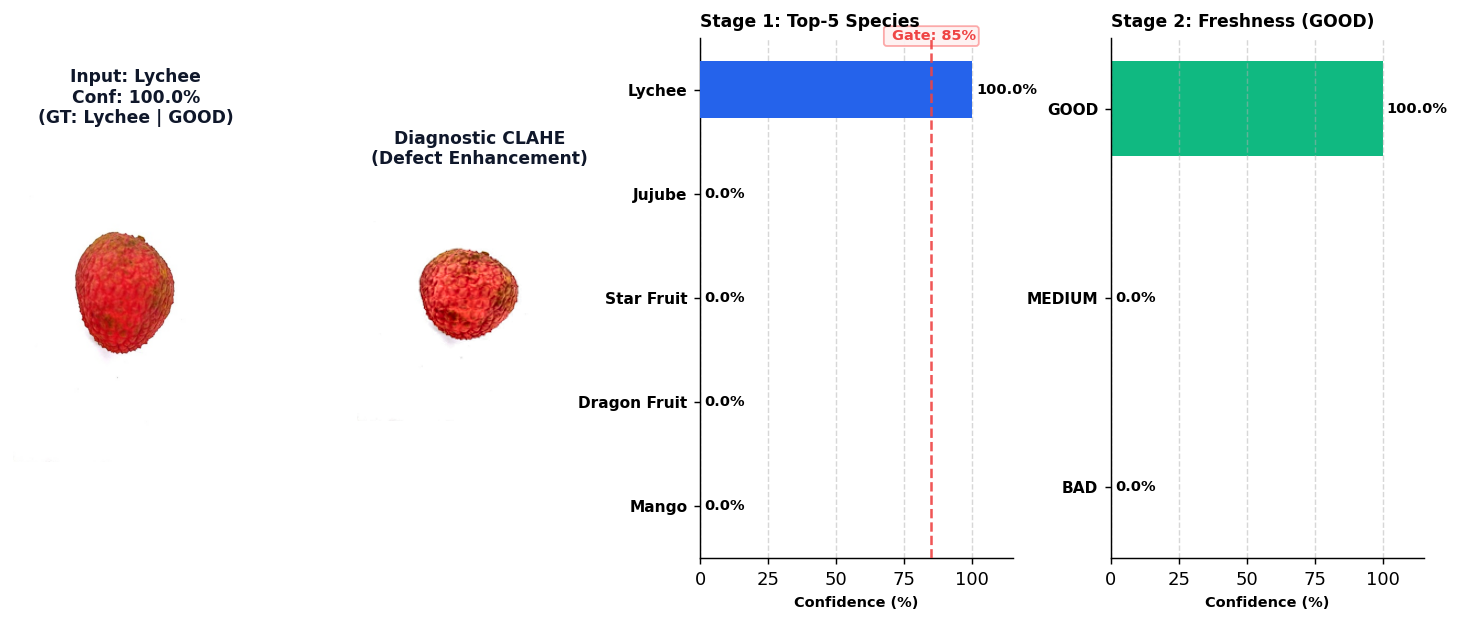


Testing Papaya (Ground Truth: MEDIUM)


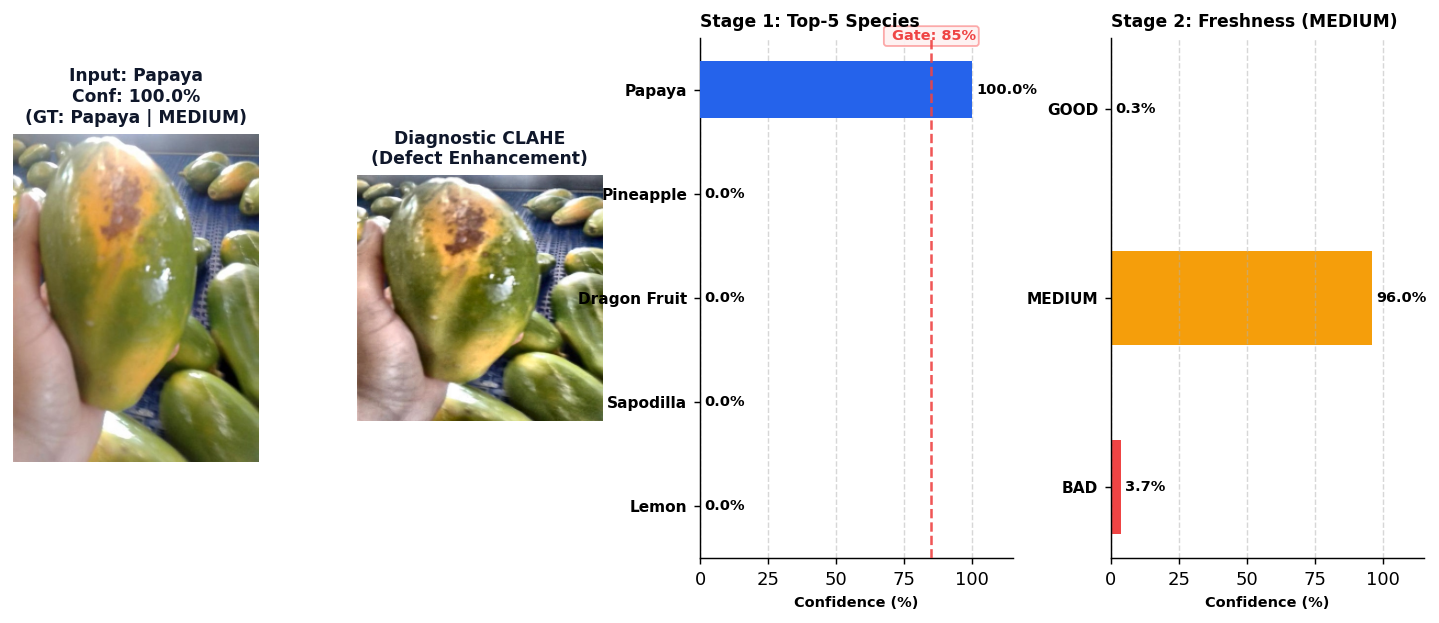

In [5]:
target_fruits = ['mango', 'banana', 'guava', 'lychee', 'papaya']

for fruit in target_fruits:
    sample_targeted = get_random_test_sample(fruit_filter=fruit)
    if sample_targeted:
        print(f"\n{'='*60}")
        print(f"Testing {fruit.title()} (Ground Truth: {sample_targeted['quality'].upper()})")
        _ = inspect_fruit_image(sample_targeted['full_path'], ground_truth=sample_targeted)


## 5. Custom Single-Image Inference
Test any image on your filesystem or in the dataset by specifying the image path below.


Running inference on: fruit_dataset_processed/test/banana/good/banana_g_1_102.jpg


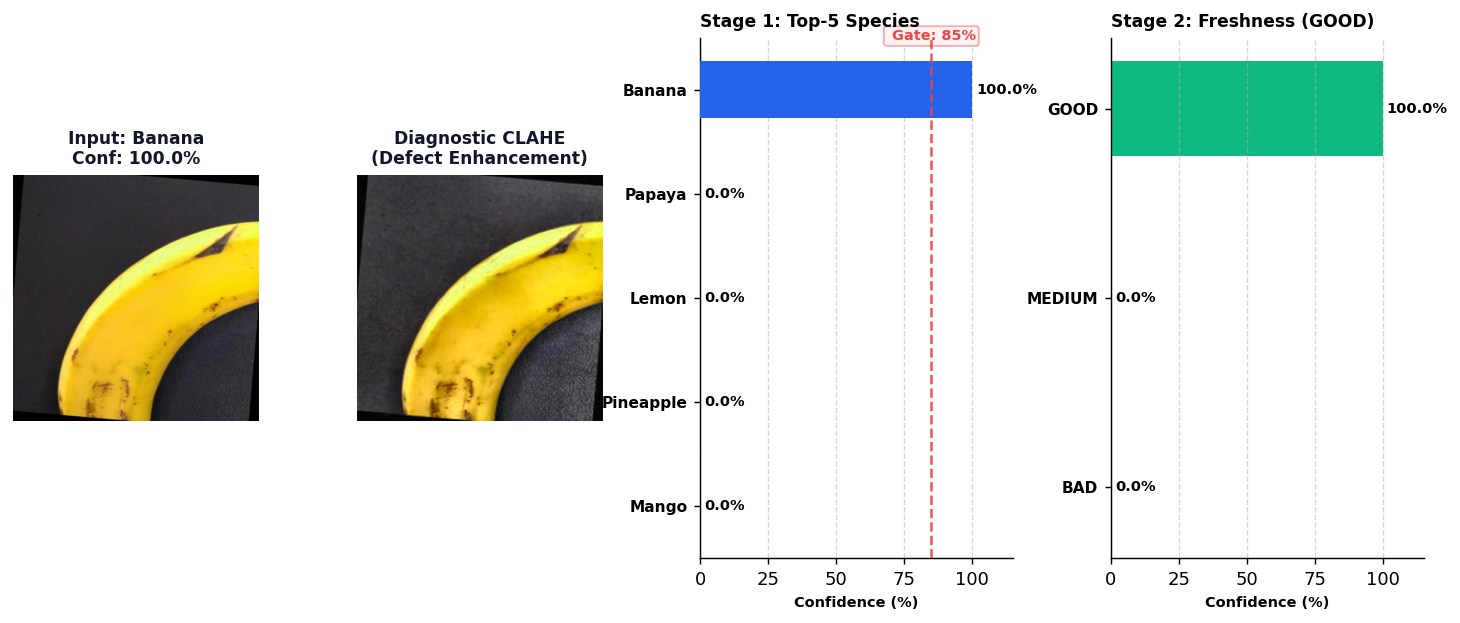

In [6]:
# Specify custom image path here:
custom_img_path = "fruit_dataset_processed/test/banana/good/banana_g_1_102.jpg"

if Path(custom_img_path).exists():
    print(f"Running inference on: {custom_img_path}")
    res_custom = inspect_fruit_image(custom_img_path, conf_threshold=0.85)
else:
    print(f"File not found: {custom_img_path}. Please set a valid path.")


## 6. Confidence Gate ($\tau$) Sensitivity Demo
The confidence gate prevents Stage 2 errors when the Stage 1 species classifier is uncertain. Here we test different threshold levels:
- Low threshold ($\tau = 0.50$): Always passes to Stage 2.
- Recommended threshold ($\tau = 0.85$): Passes only confident predictions.
- Strict threshold ($\tau = 0.9999$): Bypasses Stage 2 unless near-certain.


Sample: banana (bad)

--- Confidence Gate Threshold tau = 0.5 ---


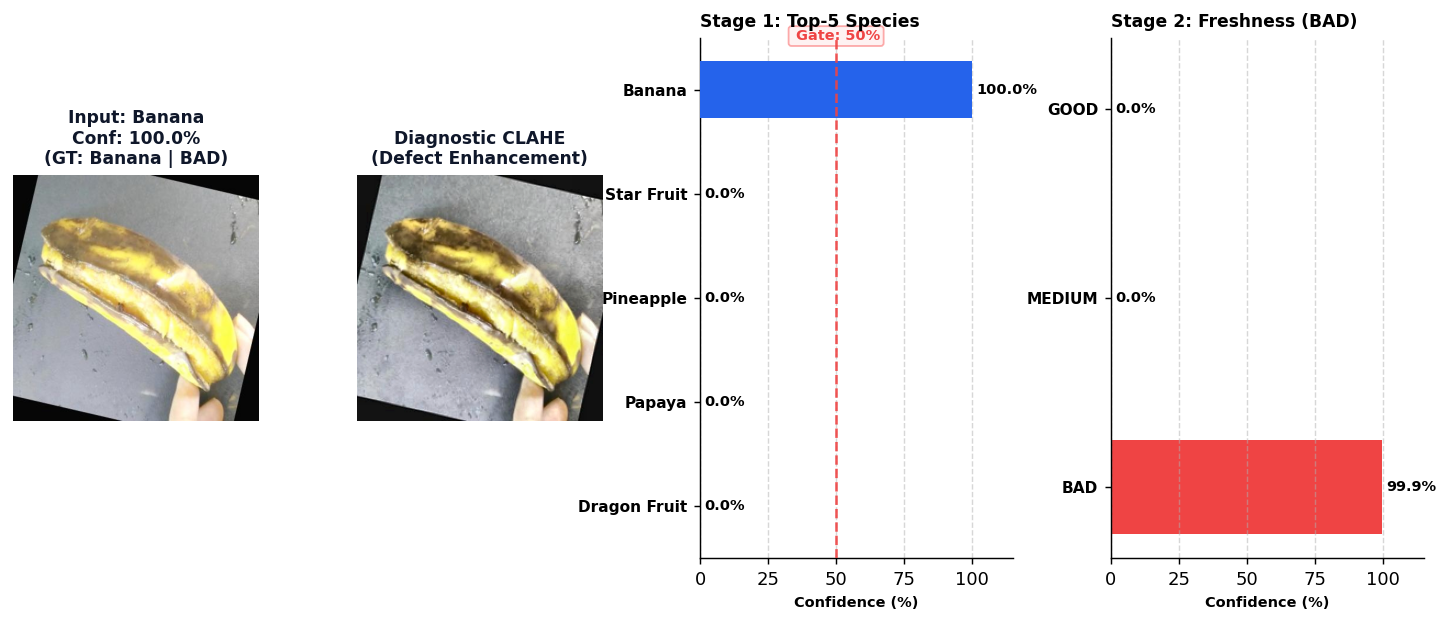


--- Confidence Gate Threshold tau = 0.85 ---


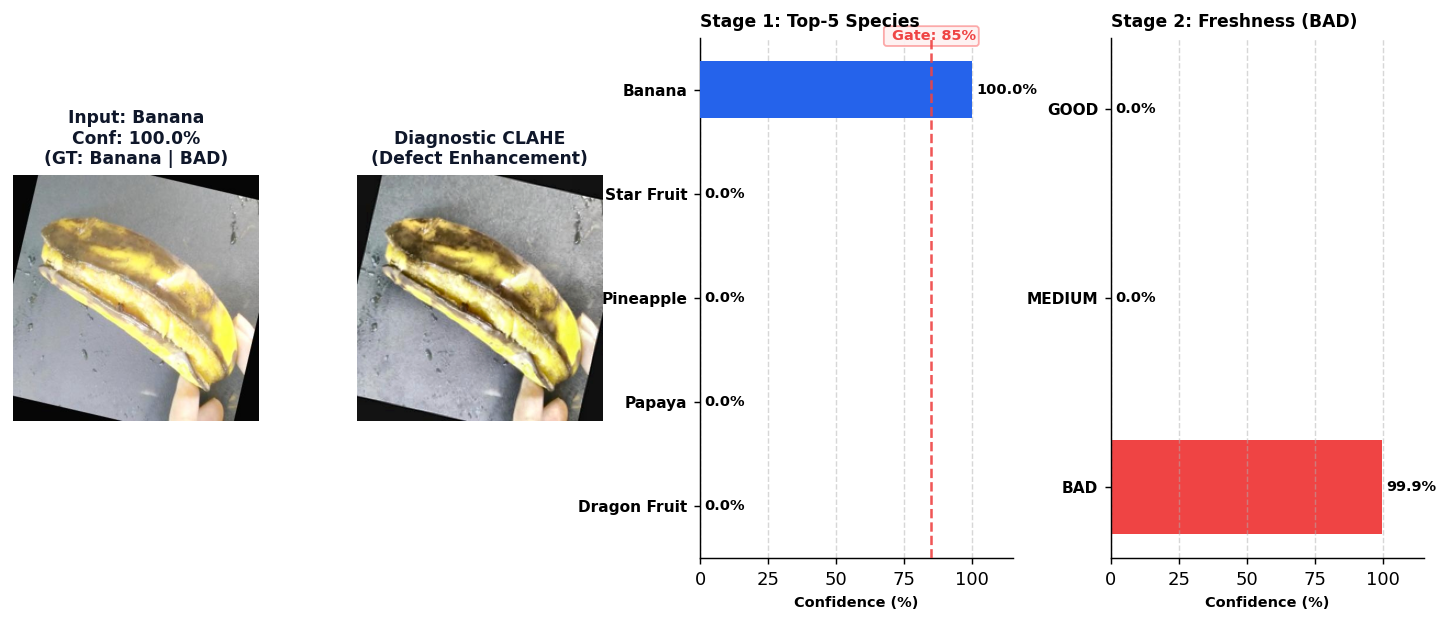


--- Confidence Gate Threshold tau = 0.9999 ---


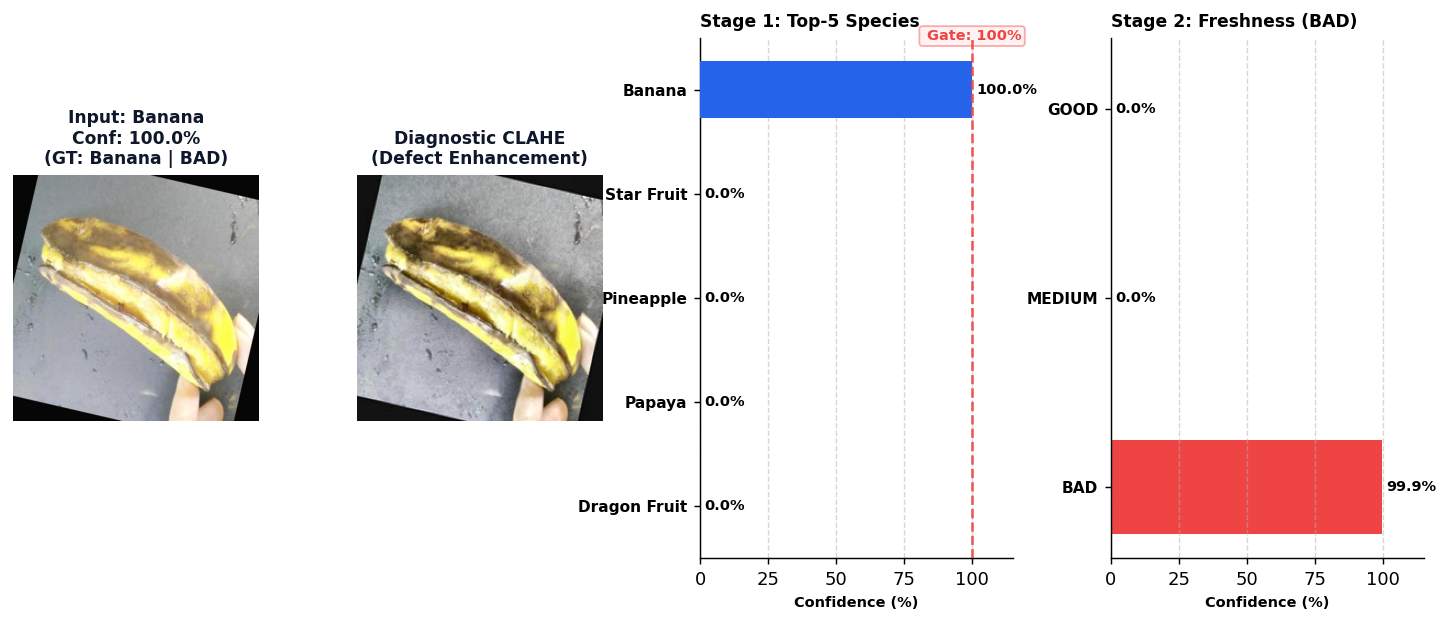

In [7]:
sample_gate = get_random_test_sample()
print(f"Sample: {sample_gate['fruit']} ({sample_gate['quality']})")

for tau in [0.50, 0.85, 0.9999]:
    print(f"\n--- Confidence Gate Threshold tau = {tau} ---")
    _ = inspect_fruit_image(sample_gate['full_path'], conf_threshold=tau, ground_truth=sample_gate)


## 7. Automated Batch Inference & Performance Evaluation
Run automated inspection on a random batch of test images, comparing predictions with Ground Truth and displaying a structured summary table.


In [8]:
manifest = get_test_manifest()
sample_batch = manifest.sample(n=10, random_state=42)

batch_records = []
print("Running batch evaluation on 10 random test images...")

for _, row in sample_batch.iterrows():
    img_path = PROJECT_ROOT / "fruit_dataset_processed" / row['rel_path']
    gt = {'fruit': row['fruit'], 'quality': row['quality']}
    
    res = inspect_fruit_image(img_path, show_plot=False, ground_truth=gt)
    
    fruit_match = (res['predicted_fruit'] == gt['fruit'])
    quality_match = (res['predicted_quality'] == gt['quality'])
    
    batch_records.append({
        "Image": row['file_name'],
        "GT Fruit": gt['fruit'].title(),
        "Pred Fruit": res['fruit_display'],
        "Fruit Conf": f"{res['fruit_confidence']*100:.1f}%",
        "Fruit Match": "✅" if fruit_match else "❌",
        "GT Quality": gt['quality'].upper(),
        "Pred Quality": res['predicted_quality'].upper(),
        "Quality Conf": f"{res['quality_confidence']*100:.1f}%" if res['stage2_executed'] else "N/A",
        "Quality Match": "✅" if quality_match else ("⚠️ Bypass" if not res['stage2_executed'] else "❌"),
        "Latency": f"{res['total_latency_ms']:.1f} ms"
    })

df_batch = pd.DataFrame(batch_records)
display(df_batch)


Running batch evaluation on 10 random test images...


,Image,GT Fruit,Pred Fruit,Fruit Conf,Fruit Match,GT Quality,Pred Quality,Quality Conf,Quality Match,Latency
0,mango_b_76.jpg,Mango,Mango,100.0%,✅,BAD,BAD,100.0%,✅,854.4 ms
1,custard_apple_m_1_107.jpg,Custard_Apple,Custard Apple,100.0%,✅,MEDIUM,MEDIUM,92.8%,✅,949.9 ms
2,star_fruit_b_34.jpg,Star_Fruit,Star Fruit,100.0%,✅,BAD,BAD,92.8%,✅,712.3 ms
3,jujube_b_3_502.jpg,Jujube,Jujube,100.0%,✅,BAD,BAD,100.0%,✅,771.7 ms
4,star_fruit_m_100.jpg,Star_Fruit,Star Fruit,100.0%,✅,MEDIUM,BAD,60.3%,❌,881.4 ms
5,jujube_g_1_631.jpg,Jujube,Jujube,100.0%,✅,GOOD,GOOD,100.0%,✅,914.7 ms
6,star_fruit_b_462.jpg,Star_Fruit,Star Fruit,100.0%,✅,BAD,BAD,99.9%,✅,878.0 ms
7,jackfruit_b_97.jpg,Jackfruit,Jackfruit,100.0%,✅,BAD,BAD,100.0%,✅,855.9 ms
8,jujube_b_2_13.jpg,Jujube,Jujube,100.0%,✅,BAD,BAD,100.0%,✅,868.1 ms
9,pineapple_m_334.jpg,Pineapple,Pineapple,100.0%,✅,MEDIUM,MEDIUM,100.0%,✅,812.0 ms


## 8. Architecture Comparison: Best Champion vs Custom CNN Baseline
Compare prediction results and latency between the Transfer Learning Champion models and the lightweight Custom CNN baselines.


Comparing Architectures on: sapodilla (medium)

--- Mode 1: Best Champion Models (ResNet-50 + MobileNetV3 / EfficientNet) ---


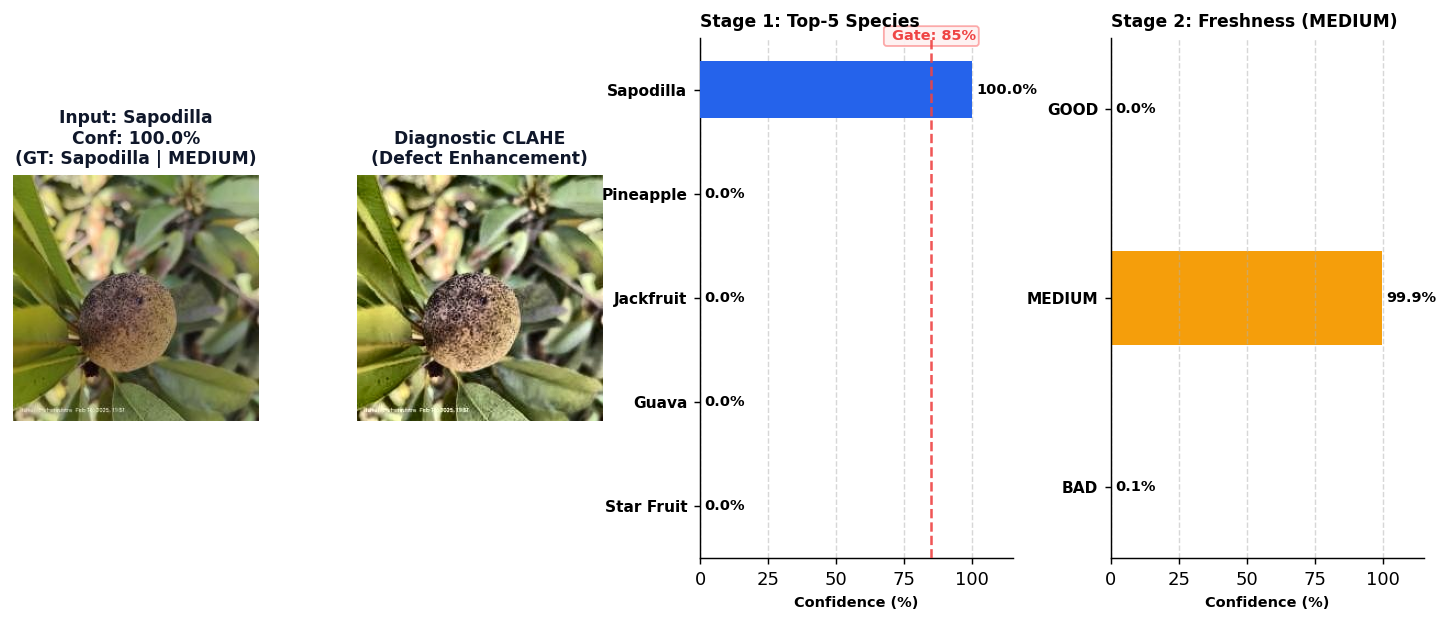


--- Mode 2: Lightweight Custom CNN Baseline ---


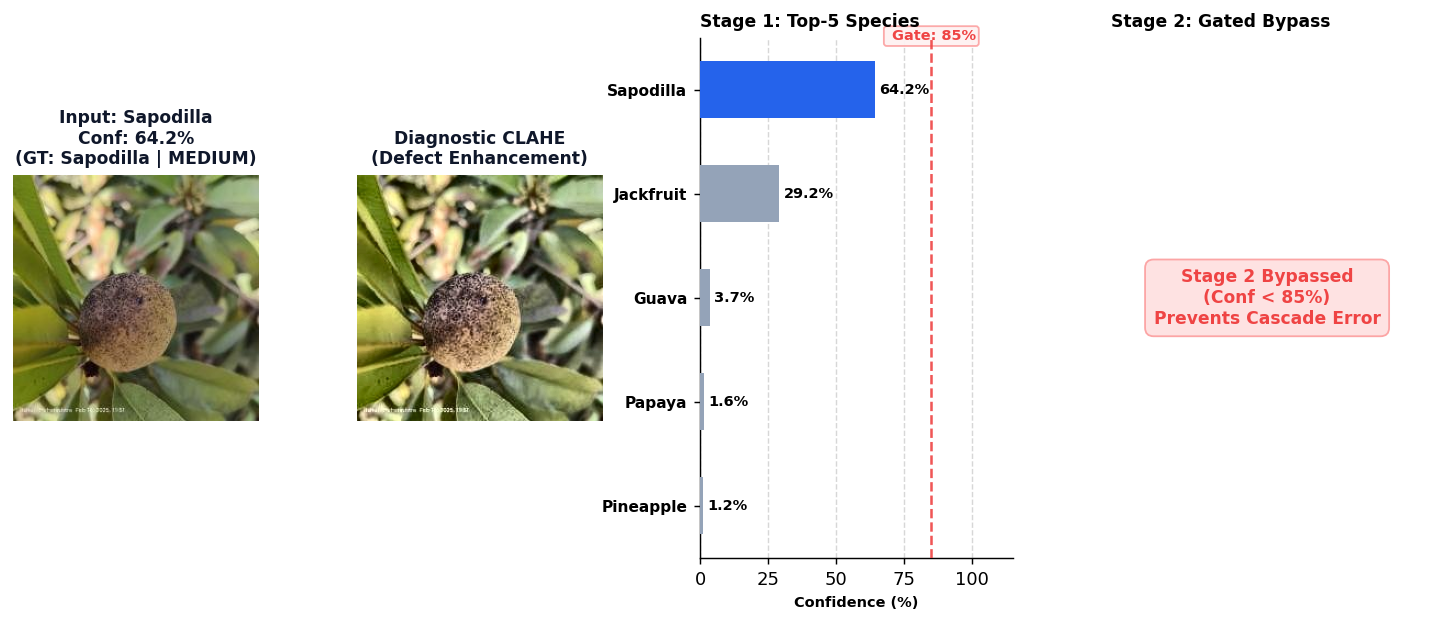


Latency Comparison Summary:
  • Best Champion Pipeline Latency:   792.16 ms
  • Custom CNN Baseline Latency:       86.30 ms


In [9]:
sample_comp = get_random_test_sample()
print(f"Comparing Architectures on: {sample_comp['fruit']} ({sample_comp['quality']})")

print("\n--- Mode 1: Best Champion Models (ResNet-50 + MobileNetV3 / EfficientNet) ---")
res_best = inspect_fruit_image(sample_comp['full_path'], mode="best", show_plot=True, ground_truth=sample_comp)

print("\n--- Mode 2: Lightweight Custom CNN Baseline ---")
res_custom = inspect_fruit_image(sample_comp['full_path'], mode="custom_cnn", show_plot=True, ground_truth=sample_comp)

print("\nLatency Comparison Summary:")
print(f"  • Best Champion Pipeline Latency:   {res_best['total_latency_ms']:.2f} ms")
print(f"  • Custom CNN Baseline Latency:       {res_custom['total_latency_ms']:.2f} ms")
